# **PROJETO AVALIATIVO - MÓDULO 1**

**Aluno:** Otávio Augusto Reis Nascimento

**Projeto:** GearGuard

**Professor:** Lucas Ribeiro de Lima

# **1. Inspecionando dados**

Carregando o DF

In [1]:
import pandas as pd

df = pd.read_csv('/content/manutencao_preditiva.csv')

Verifica o número de colunas e linhas

In [2]:
print(f"Shape do DataFrame: {df.shape}")

Shape do DataFrame: (10000, 14)


Informações sobre as colunas e tipos de dados:

In [3]:
display(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   udi                      10000 non-null  int64  
 1   id_produto               10000 non-null  object 
 2   tipo                     10000 non-null  object 
 3   temperatura_ar_k         9500 non-null   float64
 4   temperatura_processo_k   9500 non-null   float64
 5   velocidade_rotacao_rpm   9500 non-null   float64
 6   torque_nm                9500 non-null   float64
 7   desgaste_ferramenta_min  10000 non-null  int64  
 8   falha_maquina            10000 non-null  int64  
 9   falha_twf                10000 non-null  int64  
 10  falha_hdf                10000 non-null  int64  
 11  falha_pwf                10000 non-null  int64  
 12  falha_osf                10000 non-null  int64  
 13  falha_rnf                10000 non-null  int64  
dtypes: float64(4), int64(8)

None

Validação dos tipos de dados:

In [4]:
display(df.dtypes)

,0
udi,int64
id_produto,object
tipo,object
temperatura_ar_k,float64
temperatura_processo_k,float64
velocidade_rotacao_rpm,float64
torque_nm,float64
desgaste_ferramenta_min,int64
falha_maquina,int64
falha_twf,int64


Contagem de valores nulos por coluna

In [5]:
display(df.isnull().sum())

,0
udi,0
id_produto,0
tipo,0
temperatura_ar_k,500
temperatura_processo_k,500
velocidade_rotacao_rpm,500
torque_nm,500
desgaste_ferramenta_min,0
falha_maquina,0
falha_twf,0


Foi encontrado 500 valores nulos mas colunas: temperatura_ar_k, Temperatura_processo_k, velocidade_rotacao_rpm e torque_nm

Verifica os 10 primeiros registros do DF pra visualizar melhor a "sujeira".

In [6]:
display(df.head(10))

,udi,id_produto,tipo,temperatura_ar_k,temperatura_processo_k,velocidade_rotacao_rpm,torque_nm,desgaste_ferramenta_min,falha_maquina,falha_twf,falha_hdf,falha_pwf,falha_osf,falha_rnf
0,1,M14860,M,298.1,308.6,1551.0,42.8,0,0,0,0,0,0,0
1,2,L47181,L,298.2,308.7,1408.0,46.3,3,0,0,0,0,0,0
2,3,L47182,L,298.1,308.5,1498.0,49.4,5,0,0,0,0,0,0
3,4,L47183,L,NaN,NaN,NaN,NaN,7,0,0,0,0,0,0
4,5,L47184,L,298.2,308.7,1408.0,40.0,9,0,0,0,0,0,0
5,6,M14865,M,298.1,308.6,1425.0,41.9,11,0,0,0,0,0,0
6,7,L47186,L,298.1,308.6,1558.0,42.4,14,0,0,0,0,0,0
7,8,L47187,L,298.1,308.6,1527.0,40.2,16,0,0,0,0,0,0
8,9,M14868,M,298.3,308.7,1667.0,28.6,18,0,0,0,0,0,0
9,10,M14869,M,298.5,309.0,1741.0,28.0,21,0,0,0,0,0,0


Utilizando o describe() para identificar anomalias, como valores fora da faixa e a proximidade entre média e mediana para verifcar possíveis outliers.

In [7]:
display(df.describe())

,udi,temperatura_ar_k,temperatura_processo_k,velocidade_rotacao_rpm,torque_nm,desgaste_ferramenta_min,falha_maquina,falha_twf,falha_hdf,falha_pwf,falha_osf,falha_rnf
count,10000.00000,9500.000000,9500.000000,9500.000000,9500.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.00000
mean,5000.50000,300.002158,310.000895,1539.245263,39.974168,107.951000,0.033900,0.004600,0.011500,0.009500,0.009800,0.00190
std,2886.89568,2.001689,1.486432,180.273589,9.995453,63.654147,0.180981,0.067671,0.106625,0.097009,0.098514,0.04355
min,1.00000,295.300000,305.700000,1168.000000,3.800000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000
25%,2500.75000,298.300000,308.800000,1423.000000,33.100000,53.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000
50%,5000.50000,300.100000,310.100000,1504.000000,40.100000,108.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000
75%,7500.25000,301.500000,311.100000,1613.000000,46.700000,162.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000
max,10000.00000,304.500000,313.800000,2886.000000,76.600000,253.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.00000


Com as informações obtidas dos valores nulos nas colunas temperatura_ar_k, Temperatura_processo_k, velocidade_rotacao_rpm e torque_nm demonstra um ponto importante a ser analisado, pois essas métricas são importantes para entender o desempenho e saúde dos equipamentos. Esses valores ausentes podem comprometer a precisão de qualquer análise preditiva.

Vou realizar a importação do matplotlib e do seaborn, definir as variáveis preditoras para o histograma e criar os gráficos em seguida.

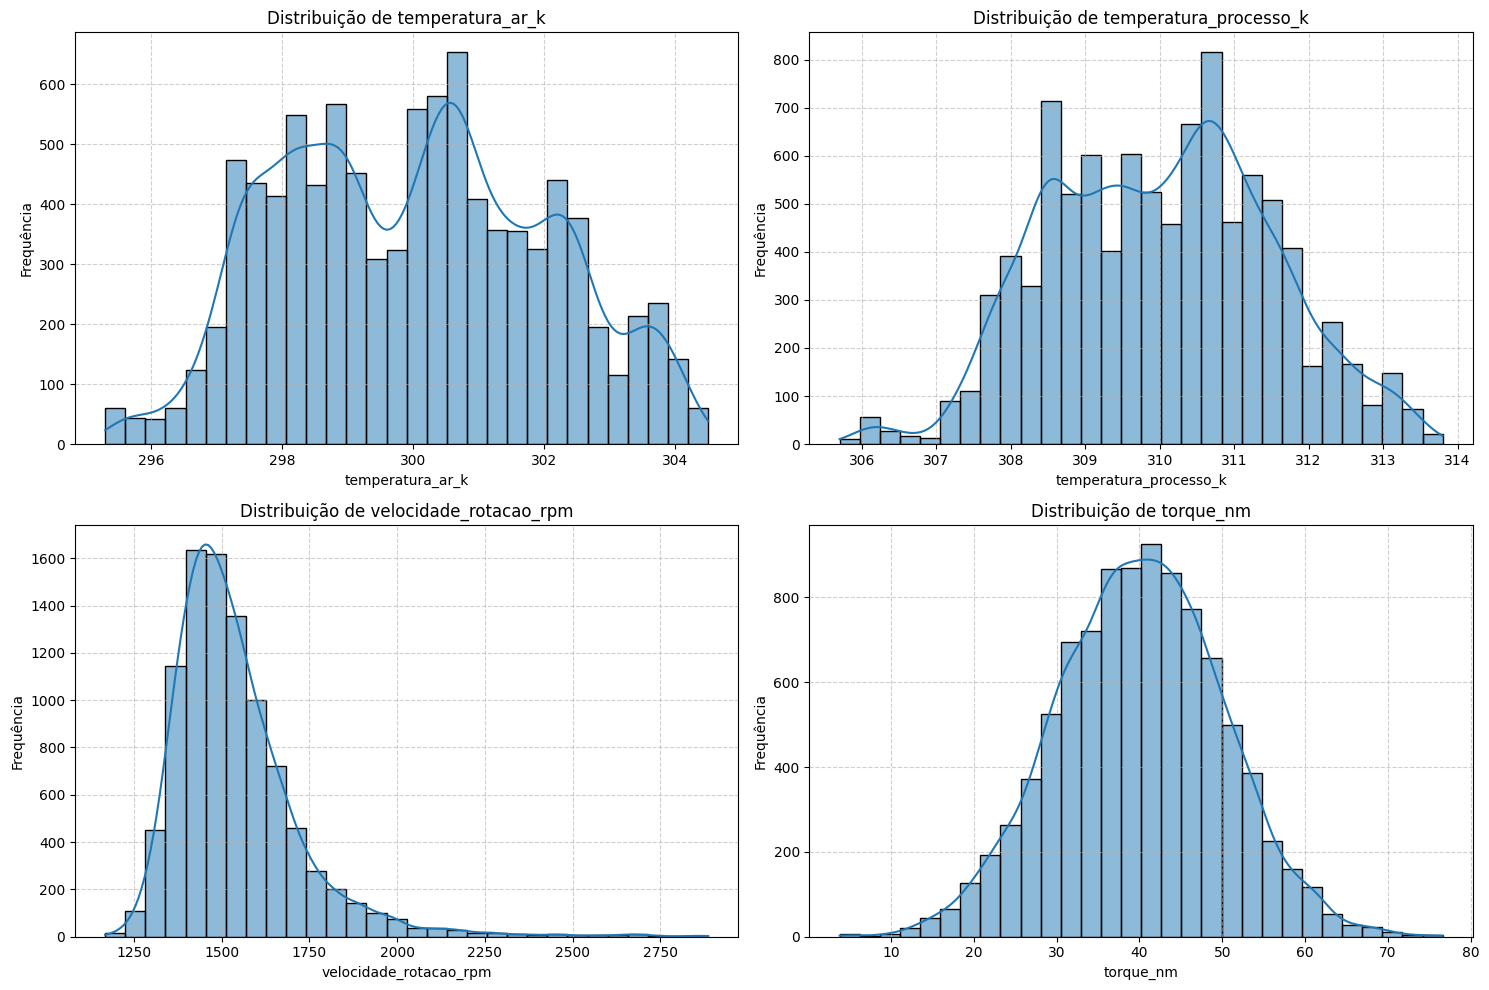

In [8]:
import matplotlib.pyplot as plt
import seaborn as sns


preditoras_vars = ['temperatura_ar_k', 'temperatura_processo_k', 'velocidade_rotacao_rpm', 'torque_nm']

fig, axes = plt.subplots(2, 2, figsize=(15, 10))
axes = axes.flatten()

for i, col in enumerate(preditoras_vars):
    sns.histplot(df[col].dropna(), kde=True, ax=axes[i], bins=30)
    axes[i].set_title(f'Distribuição de {col}')
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Frequência')
    axes[i].grid(True, linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()

Agora irei verificar a Taxa de Desbalanceamento da Variávelalvo. A variável alvo **falha_maquina** (indica se houve falha mecânica ou não) é crucial para o modelo. É fundamental verificar se há um desbalanceamento significativo entre as classes (0: sem falha, 1: com falha), pois isso pode impactar no treinamento do modelo.



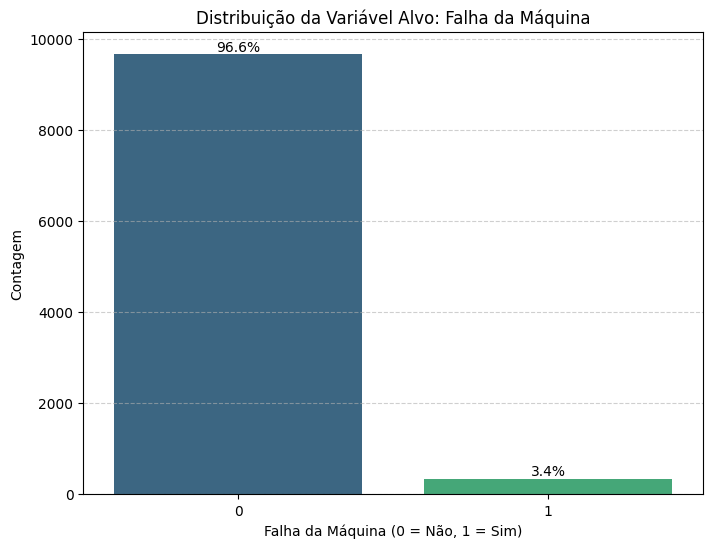

In [9]:
plt.figure(figsize=(8, 6))

sns.countplot(
    x='falha_maquina',
    data=df,
    hue='falha_maquina',
    palette='viridis',
    legend=False
)

plt.title('Distribuição da Variável Alvo: Falha da Máquina')
plt.xlabel('Falha da Máquina (0 = Não, 1 = Sim)')
plt.ylabel('Contagem')

total = len(df)

for p in plt.gca().patches:
    percentage = '{:.1f}%'.format(100 * p.get_height() / total)

    x = p.get_x() + p.get_width() / 2
    y = p.get_height()

    plt.gca().annotate(
        percentage,
        (x, y),
        ha='center',
        va='bottom'
    )

plt.grid(axis='y', linestyle='--', alpha=0.6)

plt.show()

###Mapa de Calor da Correlação de Pearson entre Variáveis Numéricas

O mapa de calor da matriz de correlação de Pearson me mostra o quanto duas variáveis se parecem no jeito que se comportam. Por exemplo, cores fortes (positiva ou negativa) significa que existe uma relação clara, quando uma aumenta a outra, também aumenta, ou então, quando uma sobe a outra desce.

As cores mais claras vão indicar que não possuem muita ligação, que cada variável segue seu caminho sem depender da outra.

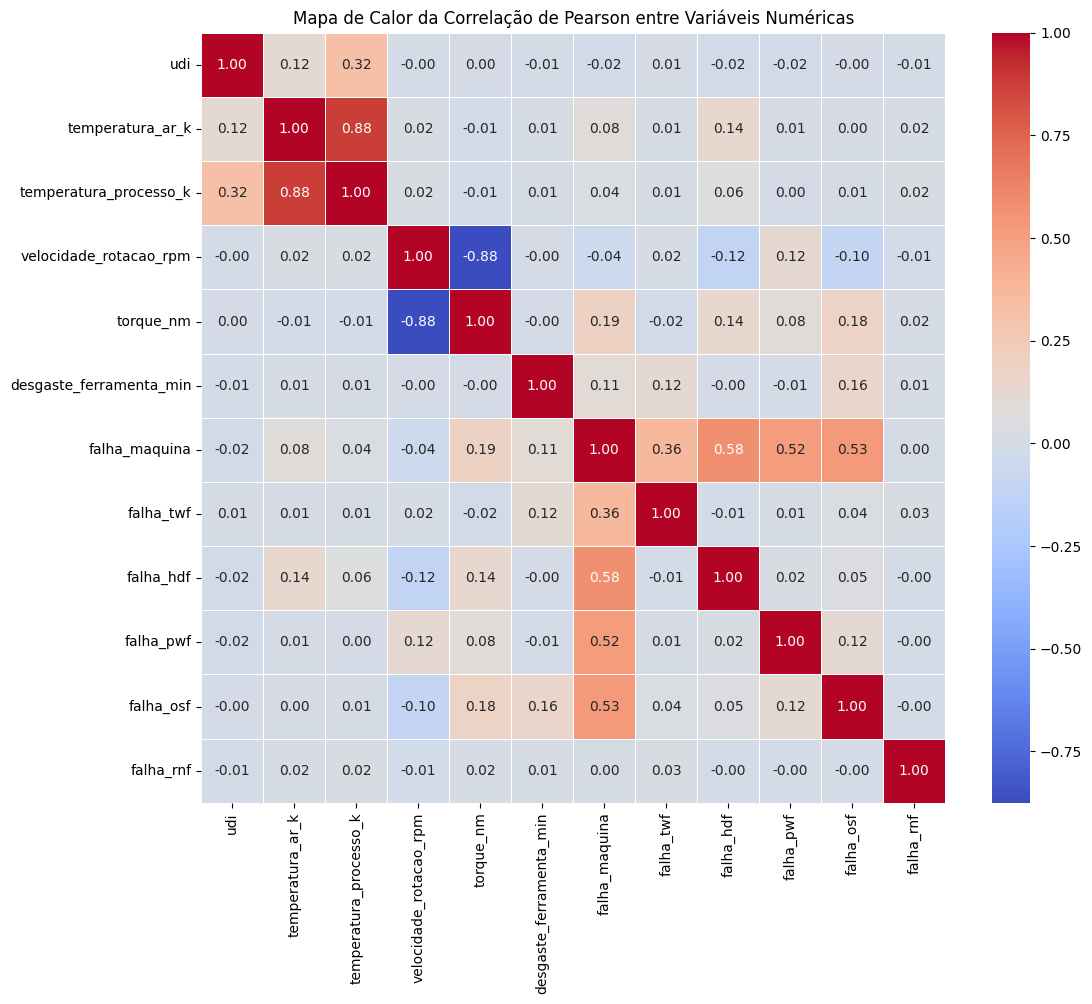

In [10]:
correlacao_matrix = df.select_dtypes(include=['float64', 'int64']).corr()

plt.figure(figsize=(12, 10))
sns.heatmap(correlacao_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=.5)
plt.title('Mapa de Calor da Correlação de Pearson entre Variáveis Numéricas')
plt.show()

# **1.1 Resultado da exploração de dados**

**Explicação do resultado:** Os dados ausentes precisam de atenção imediata, será necessario verificar se vou imputar dados ou remove-los para garantir uma integridade das análises e modelos. Os resultados demonstram que as Altas temperaturas andam juntas, ou seja, o ambiente afeta o processo. Já a velocidade e torque são opostos, porque para ter mais força (torque), geralmente a velocidade diminui e para mais velocidade a força pode ser menor. As falhas e as outras variáveis possuem correlações com as outras falhas, que também possuem uma relação com o desgaste_ferramenta_min e com a temperatura_processo_k o que podem ter uma relação na ocorrência de falhas.
**Resumindo:** É necessário tratar os dados faltantes, corrigir o desbalanceamento e considerar as relações entre variáveis para garantir que os modelos sejam confiáveis e focados em prever o que realmente importa: **as falhas.**

# **2. Limpeza e Tratamento de dados (Data Prep)**

**Identificando e removendo linhas duplicadas**

In [11]:
df.duplicated().sum()

np.int64(0)

Não foi encontrado nem uma linha duplicada no DataFrame

**Identificando os valores ausentes**

In [12]:
df.isnull().sum()

,0
udi,0
id_produto,0
tipo,0
temperatura_ar_k,500
temperatura_processo_k,500
velocidade_rotacao_rpm,500
torque_nm,500
desgaste_ferramenta_min,0
falha_maquina,0
falha_twf,0


In [13]:
df.isna().mean()

,0
udi,0.00
id_produto,0.00
tipo,0.00
temperatura_ar_k,0.05
temperatura_processo_k,0.05
velocidade_rotacao_rpm,0.05
torque_nm,0.05
desgaste_ferramenta_min,0.00
falha_maquina,0.00
falha_twf,0.00


Como já foi identificado na inspeção de dados, as colunas temperatura_ar_k, Temperatura_processo_k, velocidade_rotacao_rpm e torque_nm possuem 5% de nulos em cada coluna. Agora preciso verificar que estratégia irei utilizar para imputação com base nos valores dos dados.

**Escolha da imputação com base nos rsultados apresentados no describe()**

Através do método describe() posso verificar que a média e mediana seguem valores próximos. Isso significa que os dados têm distribuição próxima da normal e não tem muito outliers. Com base nessa informação eu pretendo prosseguir com a utilização da Média. Antes de confirmar, irei verificar a presença de outliers.

**Verificando a presença de outliers através de gráficos**

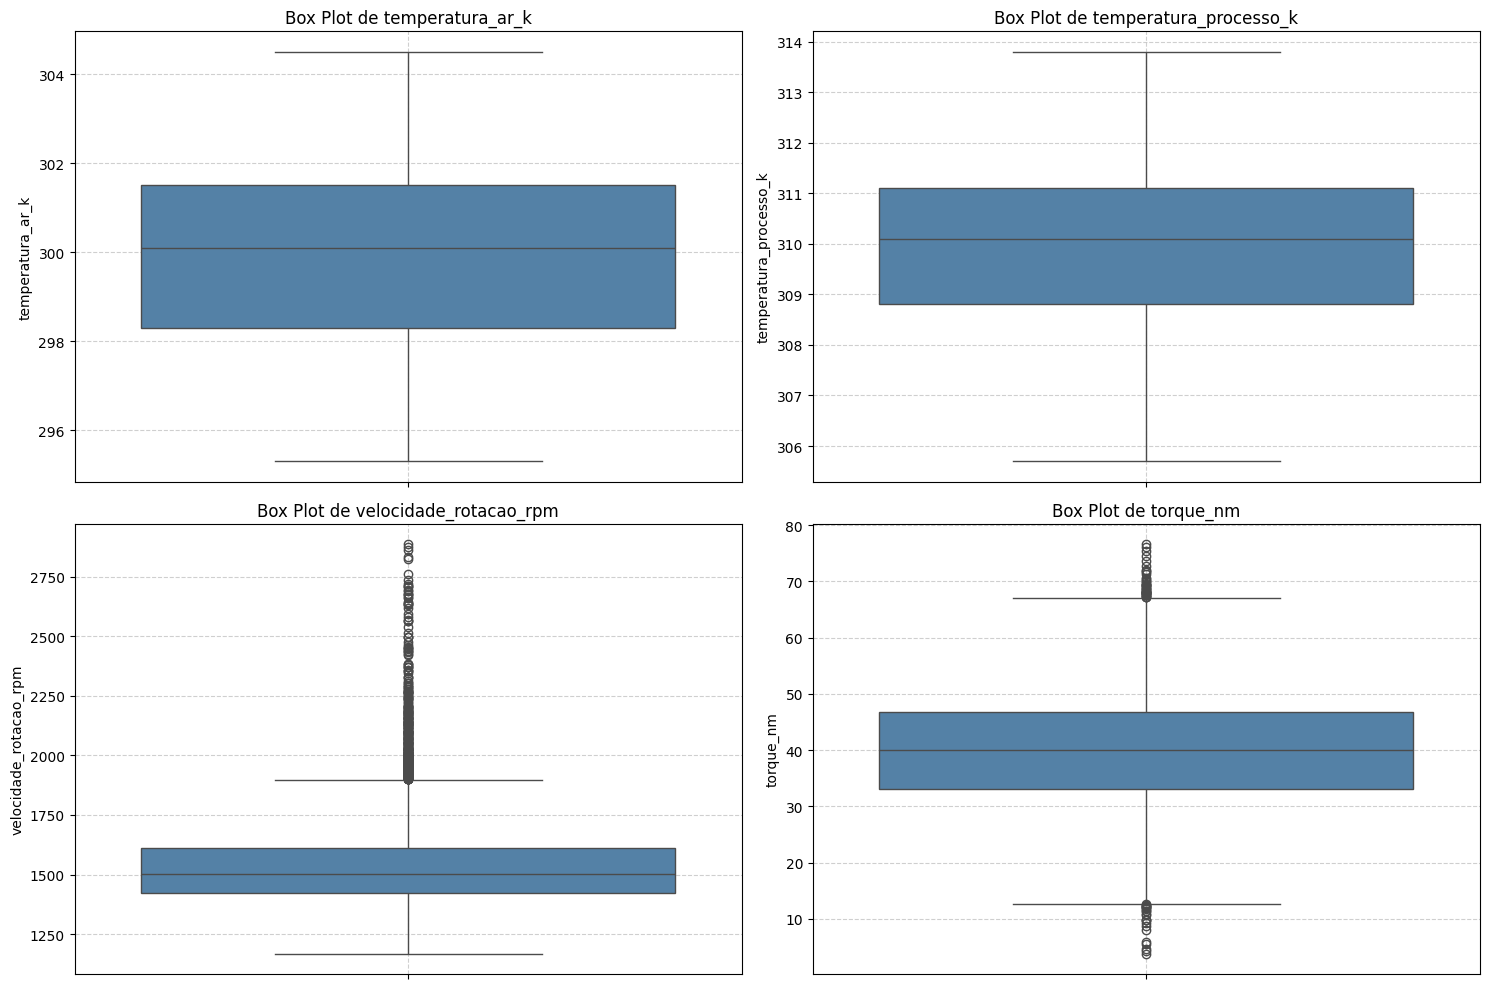

In [14]:
fig, axes = plt.subplots(2, 2, figsize=(15, 10))

axes = axes.flatten()

for i, col in enumerate(preditoras_vars):

    sns.boxplot(
        y=col,
        data=df.dropna(),
        ax=axes[i],
        color='steelblue'
    )

    axes[i].set_title(f'Box Plot de {col}')
    axes[i].set_ylabel(col)
    axes[i].grid(True, linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()

Com essa análise gráfica já posso verificar que temperatura_ar_k e temperatura_processo_k possuem valores próximos a mediana e com baxa ocorrência de outliers. Agora, visualizando velocidade_rotacao_rpm e torque_nm eu posso verificar que existe uma boa presença de outliers, ou seja, isso significa que existem máquinas trabalhando em velocidades de rotação anormalmente altas em comparação a maioria. Em relação ao torque posso verificar que possui valores abaixo e acima do esperado, ou seja, esses dois ultimos gráficos podem ser indicadores de condições de operação incomuns, de desgaste ou até falhas potenciais.

**Importante:** Essa análise foi feita foi realizada com dropna(), ou seja, os valores nulos foram removidos.

# **2.1 Decisão final sobre a imputação da média e mediana**

Com base na análise anterior eu estou prosseguindo com a imputação do valor da média para os valores nulos presentes nas colunas temperatura_ar_k e temperatura_processo_k. Para as colunas velocidade_rotacao_rpm e torque_nm será imputado a mediana, devido a presença significativa de outliers. Ao final, irei verificar se a imputação ocorreu como esperado (se os valores nulos, foram substituídos)

Preenchimento de valores nulos presentes nas colunas temperatura_ar_k e temperatura_processo_k com a média:

In [15]:
df['temperatura_ar_k'] = df['temperatura_ar_k'].fillna(df['temperatura_ar_k'].mean())

df['temperatura_processo_k'] = df['temperatura_processo_k'].fillna(df['temperatura_processo_k'].mean())

Preenchimento de valores nulos presentes nas colunas velocidade_rotacao_rpm e torque_nm com a mediana:

In [16]:
df['velocidade_rotacao_rpm'] = df['velocidade_rotacao_rpm'].fillna(df['velocidade_rotacao_rpm'].median())

df['torque_nm'] = df['torque_nm'].fillna(df['torque_nm'].median())

Verificação de valores nulos, após a imputação:

In [17]:
print('Valores nulos após a imputação:')
display(df.isnull().sum())

Valores nulos após a imputação:


,0
udi,0
id_produto,0
tipo,0
temperatura_ar_k,0
temperatura_processo_k,0
velocidade_rotacao_rpm,0
torque_nm,0
desgaste_ferramenta_min,0
falha_maquina,0
falha_twf,0


Agora, vou gerar novamente os gráficos de box plot para visualizar o impacto da imputação nos dados.

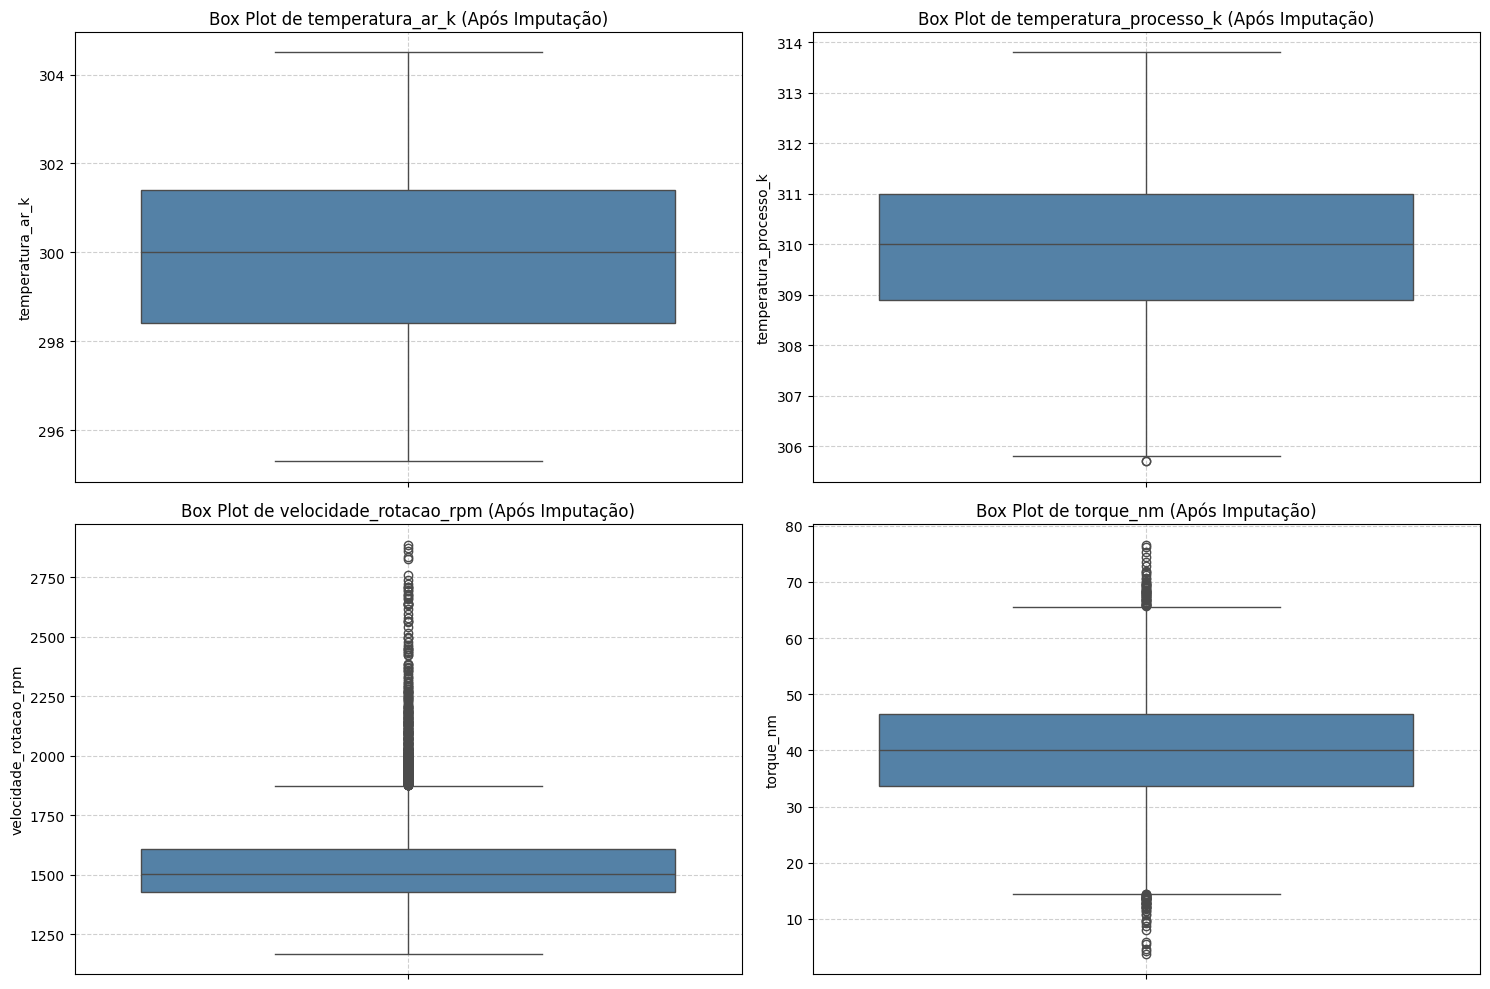

In [18]:
fig, axes = plt.subplots(2, 2, figsize=(15, 10))

axes = axes.flatten()

for i, col in enumerate(preditoras_vars):

    sns.boxplot(
        y=col,
        data=df,
        ax=axes[i],
        color='steelblue'
    )

    axes[i].set_title(f'Box Plot de {col} (Após Imputação)')
    axes[i].set_ylabel(col)
    axes[i].grid(True, linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()

**Conclusão**: Após a imputação dos dados, pude verificar que a alteração no gráfico permaneceu consistente. Com os valores nulos preenchidos e gráfico estável eu consigo prosseguir para a próxima etapa com os dados mais consistentes.

# **3. Feature Engineering**

Pelo que foi explicado em aula, eu compreendi que Feature Engineering (engenharia de atributos) é quando transformamos dados brutos/soltos em uma informação útil, ou utiliza um dado já existente para combinar com outro em sua base para responder a uma questão. Na prática, é como ter vários ingredientes (dados) que quando combinados (engenharia) da origem a uma receita (modelo).

**Features**

De acordo com a atividade a Feature sugerida é a (Manutenção) envolvendo potencia = velocidade_rotacao_rpm * torque_nm

Aproveitando a oportunidade eu decidi acrescentar "Diferença de teperatura" para verificar o quanto o processo está aquecendo em relação ao ambiente.

Outra Feature que estou adicionando também é o "Desgaste da ferramenta" para verificar as situações em que a ferramenta está mais desgastada enquanto trabalha sob maior solicitação mecânica.

**Feature 1 - Manutenção**

In [19]:
df['potencia'] = (
    df['velocidade_rotacao_rpm'] *
    df['torque_nm']
)

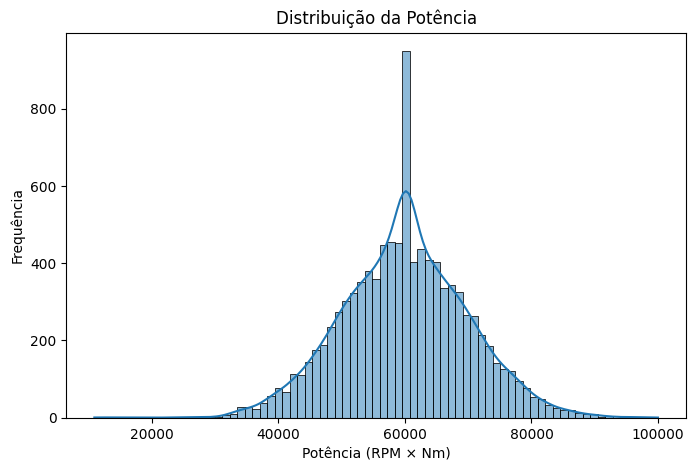

In [20]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8, 5))

sns.histplot(
    data=df,
    x='potencia',
    kde=True
)

plt.title('Distribuição da Potência')
plt.xlabel('Potência (RPM × Nm)')
plt.ylabel('Frequência')

plt.show()

Comportamento nos equipamento que falharam

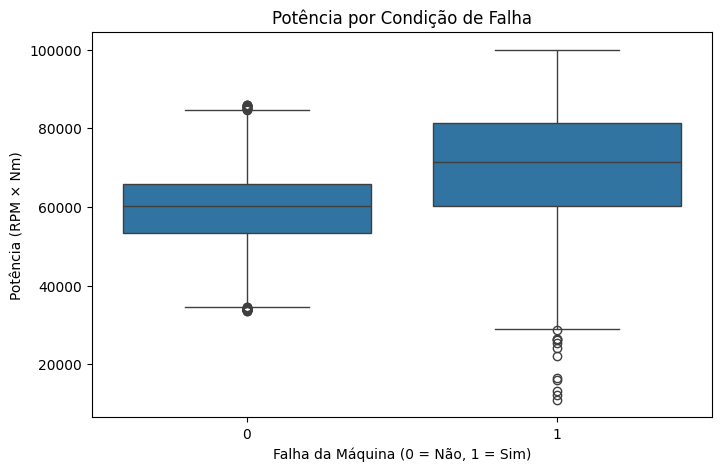

In [21]:
plt.figure(figsize=(8, 5))

sns.boxplot(
    data=df,
    x='falha_maquina',
    y='potencia'
)

plt.title('Potência por Condição de Falha')
plt.xlabel('Falha da Máquina (0 = Não, 1 = Sim)')
plt.ylabel('Potência (RPM × Nm)')

plt.show()

**Feature 2 - Diferença Temperatura**

In [22]:
df['diferenca_temperatura'] = (
    df['temperatura_processo_k'] -
    df['temperatura_ar_k']
)

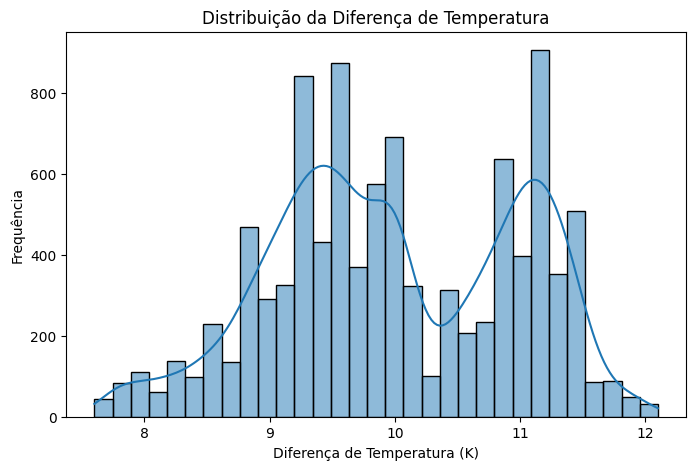

In [23]:
plt.figure(figsize=(8, 5))

sns.histplot(
    data=df,
    x='diferenca_temperatura',
    kde=True
)

plt.title('Distribuição da Diferença de Temperatura')
plt.xlabel('Diferença de Temperatura (K)')
plt.ylabel('Frequência')

plt.show()

Comportamento nos equipamento que falharam

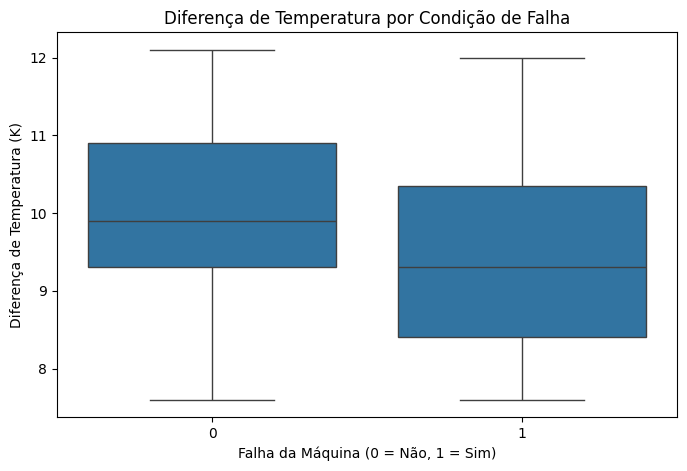

In [24]:
plt.figure(figsize=(8, 5))

sns.boxplot(
    data=df,
    x='falha_maquina',
    y='diferenca_temperatura'
)

plt.title('Diferença de Temperatura por Condição de Falha')
plt.xlabel('Falha da Máquina (0 = Não, 1 = Sim)')
plt.ylabel('Diferença de Temperatura (K)')

plt.show()

**Feature 3 - Desgaste da Ferramenta**

In [25]:
df['desgaste_por_carga'] = (
    df['desgaste_ferramenta_min'] *
    df['torque_nm']
)

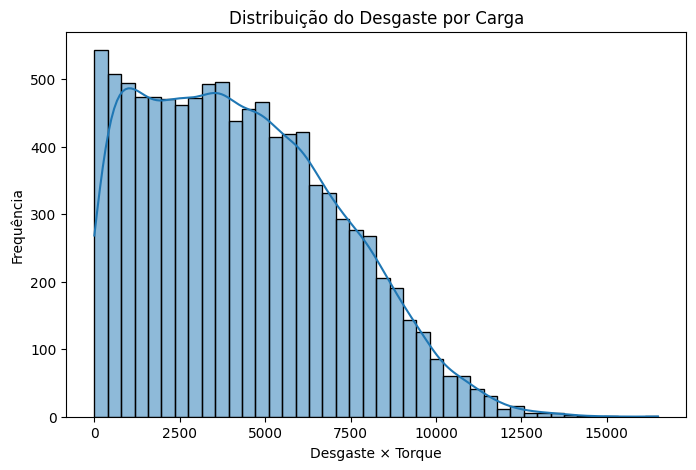

In [26]:
plt.figure(figsize=(8, 5))

sns.histplot(
    data=df,
    x='desgaste_por_carga',
    kde=True
)

plt.title('Distribuição do Desgaste por Carga')
plt.xlabel('Desgaste × Torque')
plt.ylabel('Frequência')

plt.show()

Comportamento nos equipamento que falharam

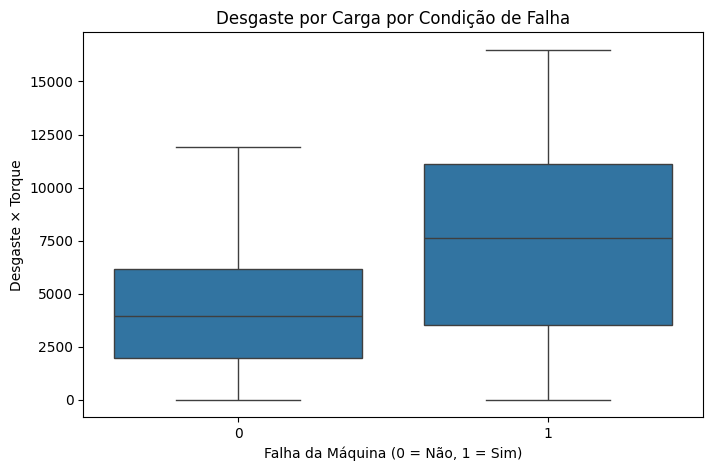

In [27]:
plt.figure(figsize=(8, 5))

sns.boxplot(
    data=df,
    x='falha_maquina',
    y='desgaste_por_carga'
)

plt.title('Desgaste por Carga por Condição de Falha')
plt.xlabel('Falha da Máquina (0 = Não, 1 = Sim)')
plt.ylabel('Desgaste × Torque')

plt.show()

# **3.1 - Explicação das Features**

**Potência (velocidade_rotacao_rpm * torque_nm):**

**Distribuição:** O histograma da potência mostra uma distribuição concentrada em torno de um pico, indicando que a maioria das operações ocorre dentro de uma faixa de potência específica. Há uma calda à direita, sugerindo operações de alta potência menos frequentes.
    
**Relação com Falha da Máquina:** O box plot de potência por falha da máquina sugere que, em geral, máquinas que falham (Falha = 1) tendem a operar com potências mais elevadas em comparação com as que não falham (Falha = 0). Isso pode indicar que o uso intensivo ou operações de alta demanda contribuem para a ocorrência de falhas.

**Diferença de Temperatura (temperatura_processo_k - temperatura_ar_k):**
  
  **Distribuição:** O histograma da diferença de temperatura exibe uma distribuição bimodal, com dois picos distintos. Isso pode indicar diferentes regimes de operação ou condições ambientais que afetam a temperatura do processo em relação ao ambiente.

  **Relação com Falha da Máquina:** O box plot da diferença de temperatura por falha da máquina mostra que, embora a mediana seja semelhante, as máquinas com falha (Falha = 1) apresentam uma distribuição um pouco mais compacta ou talvez levemente deslocada, mas não há uma distinção tão clara quanto na potência. Pequenas diferenças podem ser importantes, mas a sobreposição é grande.

**Desgaste por Carga (desgaste_ferramenta_min * torque_nm):**

**Distribuição:** O histograma do desgaste por carga mostra uma distribuição assimétrica, com a maioria dos valores concentrada em níveis mais baixos de desgaste por carga e uma cauda longa em direção a valores mais altos. Isso é esperado, pois altos níveis de desgaste sob alta carga seriam eventos menos frequentes.

**Relação com Falha da Máquina:** O box plot do desgaste por carga por falha da máquina revela uma diferença significativa. Máquinas que falham (Falha = 1) demonstram valores de desgaste por carga notavelmente mais altos, tanto na mediana quanto na dispersão, em comparação com as máquinas que não falham (Falha = 0). Isso indica que a combinação de desgaste da ferramenta e torque aplicado é um forte indicador de falha potencial.

## **4. Divisão e Balanceamento dos Dados**

De acordo com as aulas antes de treinar o modelo, preciso organizar as informações e definir claramente quais dados serão utilizados para fazer as previsões e qual informação queremos que o modelo consiga prever. Para isso irei separar as variáveis em dois grupos:

**Variáveis Preditoras (x):** Nem todas as colunas serão utilizadas, pois algumas delas são apenas um identificador dos registro e não tem características diretas com o funcionamento da máquina, como por exemplo a coluna udi e id_produto.

**Variávvel Alvo (y):** a variável falha_maquina será definida como variaável alvo y e ela informa se ocorreu ou não uma falha na máquina, sendo representada por: 0 - não ocorreu falha e 1 - oocorreu falha

In [28]:
X = df.drop(columns=['falha_maquina', 'udi', 'id_produto'])
y = df['falha_maquina']

print("Shape de X (variáveis preditoras):")
display(X.head())
print("Shape de y (variável alvo):")
display(y.head())

Shape de X (variáveis preditoras):


,tipo,temperatura_ar_k,temperatura_processo_k,velocidade_rotacao_rpm,torque_nm,desgaste_ferramenta_min,falha_twf,falha_hdf,falha_pwf,falha_osf,falha_rnf,potencia,diferenca_temperatura,desgaste_por_carga
0,M,298.100000,308.600000,1551.0,42.8,0,0,0,0,0,0,66382.8,10.500000,0.0
1,L,298.200000,308.700000,1408.0,46.3,3,0,0,0,0,0,65190.4,10.500000,138.9
2,L,298.100000,308.500000,1498.0,49.4,5,0,0,0,0,0,74001.2,10.400000,247.0
3,L,300.002158,310.000895,1504.0,40.1,7,0,0,0,0,0,60310.4,9.998737,280.7
4,L,298.200000,308.700000,1408.0,40.0,9,0,0,0,0,0,56320.0,10.500000,360.0


Shape de y (variável alvo):


,falha_maquina
0,0
1,0
2,0
3,0
4,0


**Codificação de Variáveis Categóricas**

De acordo com material disponibilizado em aula a coluna 'tipo' pode ser considerada como uma variável categórica que precisa ser convertida em um formato numérico para que os algoritmos de machine learning possa processá-la. No código abaixo irei importar o sklearn e prosseguir com a transformação da coluna 'tipo' e depois irei criar um novo df com as colunas codificadas e depois irei realizar a concatenação com o df original.

In [29]:
from sklearn.preprocessing import OneHotEncoder

encoder = OneHotEncoder(handle_unknown='ignore', sparse_output=False)

tipo_encoded = encoder.fit_transform(X[['tipo']])

tipo_df = pd.DataFrame(tipo_encoded, columns=encoder.get_feature_names_out(['tipo']), index=X.index)

X = pd.concat([X.drop(columns=['tipo']), tipo_df], axis=1)

print("Shape de X após One-Hot Encoding:")
display(X.head())

Shape de X após One-Hot Encoding:


,temperatura_ar_k,temperatura_processo_k,velocidade_rotacao_rpm,torque_nm,desgaste_ferramenta_min,falha_twf,falha_hdf,falha_pwf,falha_osf,falha_rnf,potencia,diferenca_temperatura,desgaste_por_carga,tipo_H,tipo_L,tipo_M
0,298.100000,308.600000,1551.0,42.8,0,0,0,0,0,0,66382.8,10.500000,0.0,0.0,0.0,1.0
1,298.200000,308.700000,1408.0,46.3,3,0,0,0,0,0,65190.4,10.500000,138.9,0.0,1.0,0.0
2,298.100000,308.500000,1498.0,49.4,5,0,0,0,0,0,74001.2,10.400000,247.0,0.0,1.0,0.0
3,300.002158,310.000895,1504.0,40.1,7,0,0,0,0,0,60310.4,9.998737,280.7,0.0,1.0,0.0
4,298.200000,308.700000,1408.0,40.0,9,0,0,0,0,0,56320.0,10.500000,360.0,0.0,1.0,0.0


**Divisão dos Dados em Conjuntos de Treino e Teste**

Irei dividir os dados em 80% para treino e 20% para teste. O parâmetro stratify=y irá garantir que a proporção das classes da variável alvo falha_maquina seja a mesma nos conjuntos de treino e teste, que é importante em dados desbalanceados.

Irei importar o train_test_split

In [30]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Shape de X_train: {X_train.shape}")
print(f"Shape de X_test: {X_test.shape}")
print(f"Shape de y_train: {y_train.shape}")
print(f"Shape de y_test: {y_test.shape}")

print("\nDistribuição da variável alvo em y_train:")
display(y_train.value_counts(normalize=True))
print("\nDistribuição da variável alvo em y_test:")
display(y_test.value_counts(normalize=True))

Shape de X_train: (8000, 16)
Shape de X_test: (2000, 16)
Shape de y_train: (8000,)
Shape de y_test: (2000,)

Distribuição da variável alvo em y_train:


,proportion
falha_maquina,
0,0.966125
1,0.033875



Distribuição da variável alvo em y_test:


,proportion
falha_maquina,
0,0.966
1,0.034


**Balanceamento dos Dados de Treino com SMOTE**

Dado o desbalanceamento significativo na variável alvo falha_maquina, aplicaremos a técnica SMOTE Synthetic Minority Over-sampling Technique apenas no conjunto de treino. Isso ajudará a criar amostras sintéticas da classe minoritária, balanceando o conjunto de dados para que o modelo não seja enviesado para a classe majoritária. É importante aplicar o SMOTE apenas no conjunto de treino para evitar vazamento de dados (data leakage) para o conjunto de teste.

**Reflexão:** Pelo que eu entendi, O SMOTE pega os poucos exemplos das máquinas quue falharam e cria cópias  um pouco diferente dessas falhas, mas que simula a realidade. A falha não é inventada, elas são variações das falhas que já existem, construindo assim mais exemplos de máquinas que falharam para poder aprender, sem deixar de lado as máquinas que funcionam bem. Com esses dados simulados mais próximos da realidade o modelo será mais preciso na hora de prever uma falha.

In [31]:
from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=42)

X_train_res, y_train_res = smote.fit_resample(X_train, y_train)

print(f"Shape de X_train após SMOTE: {X_train_res.shape}")
print(f"Shape de y_train após SMOTE: {y_train_res.shape}")

print("\nDistribuição da variável alvo em y_train_res após SMOTE:")
display(y_train_res.value_counts(normalize=True))

Shape de X_train após SMOTE: (15458, 16)
Shape de y_train após SMOTE: (15458,)

Distribuição da variável alvo em y_train_res após SMOTE:


,proportion
falha_maquina,
0,0.5
1,0.5


**Balanceamento dos Dados de Treino com Random Under Sampling (RUS)**

Como alternativa ao SMOTE, eu irei aplicar o Random Under Sampling (RUS) para balancear a classe minoritária e comparar os resultados.

In [32]:
from imblearn.under_sampling import RandomUnderSampler

rus = RandomUnderSampler(random_state=42)

X_train_rus, y_train_rus = rus.fit_resample(X_train, y_train)

print(f"Shape de X_train após RUS: {X_train_rus.shape}")
print(f"Shape de y_train após RUS: {y_train_rus.shape}")

print("\nDistribuição da variável alvo em y_train_rus após RUS:")
display(y_train_rus.value_counts(normalize=True))

Shape de X_train após RUS: (542, 16)
Shape de y_train após RUS: (542,)

Distribuição da variável alvo em y_train_rus após RUS:


,proportion
falha_maquina,
0,0.5
1,0.5


**Reflexão:** Pelo que eu entendi, a técnica RUS consiste na remoção aleatória exemplos da classe majoritária, que são as máquinas que trabalham bem, para euqualizar com as máquinas que falham, para a máquina aprender de forma mais equilibrada. A vantagem que encontrei, é qu eo conjunto de dados fica menor e o treinamento passa a ser mais rápido. A desvantagem é o descarte de dados reais, que pode fazer o modelo perca informações importantes que estavam na classe majoritária

## **4.1 Explicação da escolha SMOTE ou RUS**

No final eu decidi aplicar às técnicas SMOTE e RUS para verificar o desempenho em cada uma, porém como eu preciso de mais dados para meu modelo prever futuras falhas eu acredito que a técnica SMOTE corresponde a melhor escolha para o modelo, já que os dados são preservados e ele irá criar exemplos novos e sintéticos das falhas para utilizar no seu aprendizado.


# **5. Escalonamento de Variáveis (Standard Scaler)**

De acordo com o material disponibilizado nas aulas eu compreendi que a utilização do StandardScaler serve para nivelar os valores das variáveis, para que tenham o mesmo peso na análise. Por exemplo, a rotação ser de 0 a 1.000 e a outra variável ser apenas 0 e 1, o standard scaler irá trata-las de forma igual. Assim o modelo irá avaliar a semelhança entre os dados de forma justa, sem deixar a variável de número maior influenciar no resultado, só porque tem números maiores. Entendi também que variáveis 0 e 1, não precisam de escalonamento porque já estão na mesma escala (sim/não, verdadeiro/falso)

**Aplicação do KNN**: Depois da utilização do Standard Scaler que serve para nivelar os dados de forma justa, vejo o KNN como uma forma de agrupar os resultados mais próximos e decide a classificação ou previsão com base neles.

In [33]:
from sklearn.preprocessing import StandardScaler

colunas_continuas = [
    'temperatura_ar_k', 'temperatura_processo_k', 'velocidade_rotacao_rpm', 'torque_nm',
    'desgaste_ferramenta_min', 'potencia', 'diferenca_temperatura', 'desgaste_por_carga'
]

scaler = StandardScaler()

X_train_res_scaled = X_train_res.copy()
X_train_res_scaled[colunas_continuas] = scaler.fit_transform(X_train_res[colunas_continuas])

X_test_scaled = X_test.copy()
X_test_scaled[colunas_continuas] = scaler.transform(X_test[colunas_continuas])

print("Dados de treino escalonados (primeiras 10 linhas):")
display(X_train_res_scaled.head(10))

print("Dados de teste escalonados (primeiras 10 linhas):")
display(X_test_scaled.head(10))

Dados de treino escalonados (primeiras 10 linhas):


,temperatura_ar_k,temperatura_processo_k,velocidade_rotacao_rpm,torque_nm,desgaste_ferramenta_min,falha_twf,falha_hdf,falha_pwf,falha_osf,falha_rnf,potencia,diferenca_temperatura,desgaste_por_carga,tipo_H,tipo_L,tipo_M
0,-0.211087,-0.107527,-0.060141,-0.320543,-0.995560,0,0,0,0,0,-0.277557,0.253429,-0.905218,0.0,0.0,1.0
1,-1.804463,-1.421669,-0.419352,0.126669,0.112004,0,0,0,0,1,0.034194,1.528931,0.125173,0.0,0.0,1.0
2,0.318512,1.127971,-0.563037,0.069880,0.183002,0,0,0,0,0,-0.171310,0.842789,0.157026,0.0,0.0,1.0
3,-0.796050,-0.262742,-0.378300,0.829432,-0.569574,0,0,0,0,0,1.017944,1.136850,-0.238017,0.0,1.0,0.0
4,-1.751389,-1.267145,0.723282,-1.129785,-1.052358,0,0,0,0,0,-0.993631,1.626951,-1.095296,0.0,1.0,0.0
5,-1.114496,-0.958098,0.630914,-0.909728,-1.648739,0,0,0,0,0,-0.687942,0.842789,-1.402534,1.0,0.0,0.0
6,0.159289,0.664400,-0.884617,0.545487,-0.285583,0,0,0,0,0,0.111488,0.548728,-0.053247,0.0,0.0,1.0
7,-1.486017,-0.880836,-0.371458,-0.313445,-1.038159,0,0,0,0,0,-0.515122,1.626951,-0.935197,1.0,0.0,0.0
8,1.857668,2.364160,0.295649,-0.285050,-0.640571,0,0,0,0,0,0.059333,-0.431476,-0.634049,0.0,0.0,1.0
9,-1.645240,-1.189883,-0.309878,-0.185670,-0.214585,0,0,0,0,0,-0.291671,1.528931,-0.277365,1.0,0.0,0.0


Dados de teste escalonados (primeiras 10 linhas):


,temperatura_ar_k,temperatura_processo_k,velocidade_rotacao_rpm,torque_nm,desgaste_ferramenta_min,falha_twf,falha_hdf,falha_pwf,falha_osf,falha_rnf,potencia,diferenca_temperatura,desgaste_por_carga,tipo_H,tipo_L,tipo_M
2997,0.053140,-0.262742,-0.604090,1.283743,0.410195,0,0,0,0,0,1.349267,-0.431476,1.027760,0.0,1.0,0.0
4871,1.751520,1.746065,-0.029351,-0.320543,0.154603,0,0,0,0,0,-0.253115,-1.019598,-0.059935,0.0,1.0,0.0
3858,1.114627,0.973447,0.128017,-0.498009,1.205369,0,0,0,0,0,-0.392147,-0.823557,0.576323,0.0,1.0,0.0
951,-2.547504,-2.966905,-0.043036,-0.625784,-0.910363,0,0,0,0,0,-0.703424,0.940809,-0.909746,1.0,0.0,0.0
6463,0.053140,-0.108218,-0.559616,1.120475,-0.313982,0,0,0,0,0,1.192938,-0.235435,0.134542,1.0,0.0,0.0
3264,0.477735,-0.030956,-0.227773,-0.036599,0.907179,0,0,0,0,0,-0.016471,-0.921577,0.688851,1.0,0.0,0.0
4508,1.061553,-0.108218,-0.326984,0.140866,-0.313982,0,0,0,0,0,0.138355,-2.097822,-0.231771,0.0,1.0,0.0
2100,-0.583753,-0.649051,-0.173036,0.098275,-1.165954,0,0,0,0,0,0.220600,0.254667,-0.965957,0.0,0.0,1.0
7885,0.159289,1.668804,0.234070,-0.590291,-0.441778,0,0,0,0,0,-0.453194,1.822992,-0.590198,0.0,1.0,0.0
2421,-0.796050,-1.498930,2.950393,-2.102295,-1.492544,0,0,0,0,0,-1.940228,-0.431476,-1.394571,0.0,1.0,0.0


Verificando a média e desvio padrão das colunas contínuas:

In [34]:
print("Média das colunas contínuas em X_train_res_scaled:")
display(X_train_res_scaled[colunas_continuas].mean().round(2))

print("Desvio padrão das colunas contínuas em X_train_res_scaled:")
display(X_train_res_scaled[colunas_continuas].std().round(2))

Média das colunas contínuas em X_train_res_scaled:


,0
temperatura_ar_k,-0.0
temperatura_processo_k,-0.0
velocidade_rotacao_rpm,0.0
torque_nm,-0.0
desgaste_ferramenta_min,-0.0
potencia,0.0
diferenca_temperatura,-0.0
desgaste_por_carga,0.0


Desvio padrão das colunas contínuas em X_train_res_scaled:


,0
temperatura_ar_k,1.0
temperatura_processo_k,1.0
velocidade_rotacao_rpm,1.0
torque_nm,1.0
desgaste_ferramenta_min,1.0
potencia,1.0
diferenca_temperatura,1.0
desgaste_por_carga,1.0


# **5.1 Árvore de Decisão e a imunidade da escala dos atributos**

Pelo que compreendi a Árvore de Decisão funciona como um fluxo de perguntas e respostas, sim e não, até chegar uma decisão final,por exemplo, "a maquina vai falhar" ou "não vai falhar". Ela não irá realizar cálculos, ela irá apenas comparar valores relativos dentro da própria variável, ou seja, ela irá analisar cada atributo de forma isolada.

**Por que é imune?**  Porque cada pergunta é independente e só faz sentido dentro daquela caracteristica, sen se importar com a escala. Importando apenas a resposta da pergunta de cada parte do fluxo.

# **6. Ajuste de Parâmetros e Combate ao Overfitting**

Nesta etapa, o meu objetivo é encontrar uma configuração adequada para o modelo, irei ajustar seus parâmetros para que ele consiga aprender os padrões existentes nos dados sem ficar excessivamente adaptado ao conjunto utilizado no treinamento. Como o próprio nome dessa sessão já diz, eu preciso combater o oferfitting e também o underfitting, caso ocorra. Irei tentar escolher um equilíbrio entre a capacidade de aprendizado e a capacidade de generalização do modelo. Para isso irei precisar verificar os resultado obtidos pela árvore de decisão e do KNN.

**Treinamento e Avaliação do Modelo KNN**

In [38]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score

valores_k = [3, 5, 7]

print("\n--- Treinamento e Avaliação do Modelo KNN ---")
resultados_knn = []

for k in valores_k:

    knn = KNeighborsClassifier(n_neighbors=k)

    knn.fit(X_train_res_scaled, y_train_res)

    y_treino_pred_knn = knn.predict(X_train_res_scaled)

    y_teste_pred_knn = knn.predict(X_test_scaled)

    acuracia_treino_knn = accuracy_score(y_train_res, y_treino_pred_knn)
    acuracia_teste_knn = accuracy_score(y_test, y_teste_pred_knn)

    resultados_knn.append({
        'K': k,
        'Acurácia (Treino)': acuracia_treino_knn,
        'Acurácia (Teste)': acuracia_teste_knn
    })

    print(f"\nK = {k}:")
    print(f"  Acurácia (Treino): {acuracia_treino_knn:.4f}")
    print(f"  Acurácia (Teste): {acuracia_teste_knn:.4f}")

resultados_knn = pd.DataFrame(resultados_knn)

resultados_knn = resultados_knn.round(3)

display(resultados_knn)


--- Treinamento e Avaliação do Modelo KNN ---

K = 3:
  Acurácia (Treino): 0.9917
  Acurácia (Teste): 0.9695

K = 5:
  Acurácia (Treino): 0.9862
  Acurácia (Teste): 0.9635

K = 7:
  Acurácia (Treino): 0.9832
  Acurácia (Teste): 0.9585


,K,Acurácia (Treino),Acurácia (Teste)
0,3,0.992,0.970
1,5,0.986,0.964
2,7,0.983,0.958


**Árvore de Decisão e Profundidade**

In [49]:
from sklearn.tree import DecisionTreeClassifier

valores_profundidade = [3, 5, 7, None]

print("\n--- Treinamento e Avaliação do Modelo de Árvore de Decisão ---")
resultados_arvore = []

for profundidade in valores_profundidade:

    arvore = DecisionTreeClassifier(
        max_depth=profundidade,
        random_state=42
    )

    arvore.fit(X_train_res_scaled, y_train_res)

    y_treino_pred_arvore = arvore.predict(X_train_res_scaled)

    y_teste_pred_arvore = arvore.predict(X_test_scaled)

    acuracia_treino_arvore = accuracy_score(
        y_train_res,
        y_treino_pred_arvore
    )

    acuracia_teste_arvore = accuracy_score(
        y_test,
        y_teste_pred_arvore
    )

    resultados_arvore.append({
        'Profundidade Máxima': str(profundidade),
        'Acurácia (Treino)': acuracia_treino_arvore,
        'Acurácia (Teste)': acuracia_teste_arvore
    })

    print(f"\nProfundidade Máxima = {str(profundidade)}:")
    print(f"  Acurácia (Treino): {acuracia_treino_arvore:.4f}")
    print(f"  Acurácia (Teste): {acuracia_teste_arvore:.4f}")

resultados_arvore = pd.DataFrame(resultados_arvore)

resultados_arvore = resultados_arvore.round(3)

display(resultados_arvore)


--- Treinamento e Avaliação do Modelo de Árvore de Decisão ---

Profundidade Máxima = 3:
  Acurácia (Treino): 0.8861
  Acurácia (Teste): 0.8445

Profundidade Máxima = 5:
  Acurácia (Treino): 0.9428
  Acurácia (Teste): 0.9870

Profundidade Máxima = 7:
  Acurácia (Treino): 0.9545
  Acurácia (Teste): 0.9840

Profundidade Máxima = None:
  Acurácia (Treino): 1.0000
  Acurácia (Teste): 0.9755


,Profundidade Máxima,Acurácia (Treino),Acurácia (Teste)
0,3,0.886,0.844
1,5,0.943,0.987
2,7,0.954,0.984
3,None,1.000,0.976


**Analisando resultados graficamente do KNN e Árvore de Decisão**

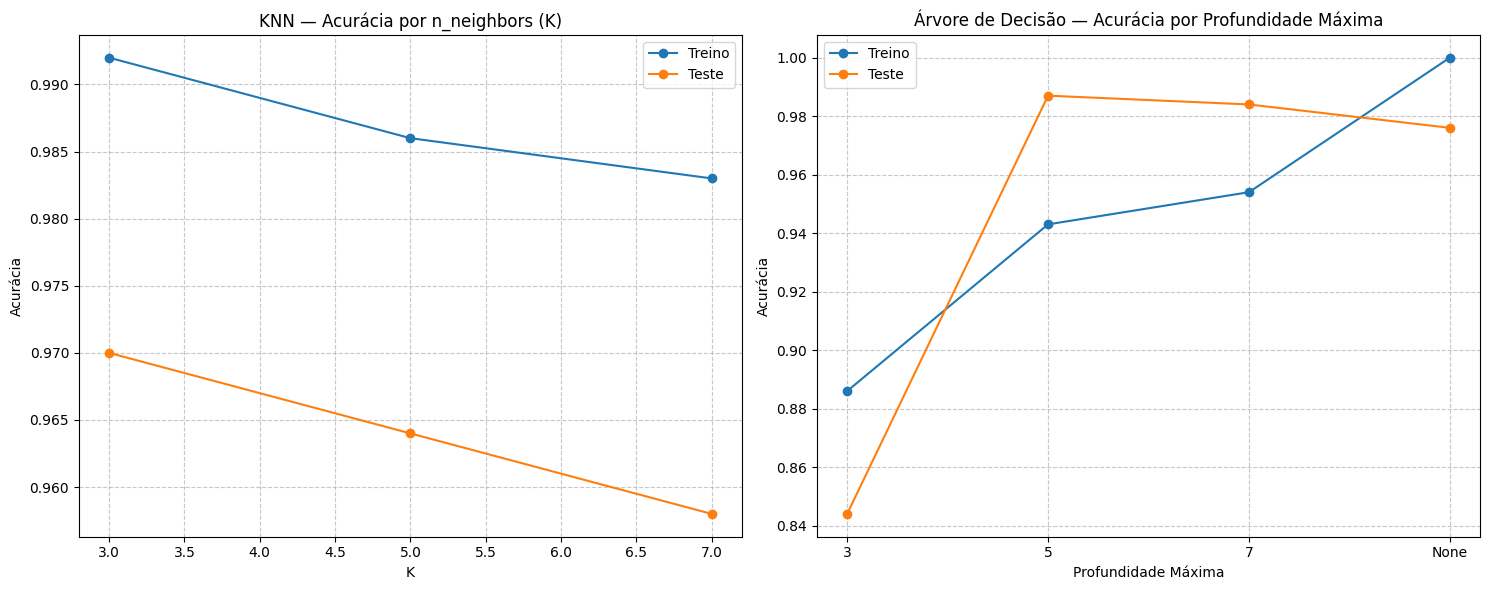

In [50]:
import matplotlib.pyplot as plt
import seaborn as sns

fig, axes = plt.subplots(1, 2, figsize=(15, 6))

axes[0].plot(resultados_knn["K"], resultados_knn["Acurácia (Treino)"], marker="o", label="Treino")
axes[0].plot(resultados_knn["K"], resultados_knn["Acurácia (Teste)"], marker="o", label="Teste")
axes[0].set_title("KNN — Acurácia por n_neighbors (K)")
axes[0].set_xlabel("K")
axes[0].set_ylabel("Acurácia")
axes[0].legend()
axes[0].grid(True, linestyle='--', alpha=0.7)

rotulos_depth = [str(d) for d in resultados_arvore["Profundidade Máxima"]]
axes[1].plot(rotulos_depth, resultados_arvore["Acurácia (Treino)"], marker="o", label="Treino")
axes[1].plot(rotulos_depth, resultados_arvore["Acurácia (Teste)"], marker="o", label="Teste")
axes[1].set_title("Árvore de Decisão — Acurácia por Profundidade Máxima")
axes[1].set_xlabel("Profundidade Máxima")
axes[1].set_ylabel("Acurácia")
axes[1].legend()
axes[1].grid(True, linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

**Resultados KNN E da Àrvore de decisão**

In [51]:
display(resultados_knn)
display(resultados_arvore)

,K,Acurácia (Treino),Acurácia (Teste)
0,3,0.992,0.970
1,5,0.986,0.964
2,7,0.983,0.958


,Profundidade Máxima,Acurácia (Treino),Acurácia (Teste)
0,3,0.886,0.844
1,5,0.943,0.987
2,7,0.954,0.984
3,None,1.000,0.976


# **6.1 Identificação do Overfitting**

Analisando os gráficos e tabelas eu compreendi que, no modelo KNN ele irá agrupar os "vizinhos" mais próximos e no modelo de Àrvore de decisão ela vai criar um fluxo de acordo com o nível de profundidade (espécie de enraizamento).

O modelo que apresenta o Overfitting, seria da Àrvore de decisão, cheguei nessa dedução porque quando ela chega na profundidade None e seu treino atinge 100% a acurácia do teste começa a cair, e mesmo depois que é adicionado uma nova profundidade 7, ela continua caindo levemente. Significa que com os dados presentes (antigos) ela irá acertar tudo, porém com a vinda de novos dados ela acaba perdendo levemente a acurácia por conta do nível de profundidade.

O modelo KNN apresentou maior estabilidade na acurácia de teste com uma variação de 1.2 ponto percentual. Já na árvore de decisão, na profundidade 3 para 5, é possível identificar uma variação maior, porém, a partir da profundidade 5 e adicionando a 7 e depois indo para o none, podemos identificar um comportamento mais consistente.

